Implementation of Logistic Regression


In [1]:
import numpy as np

In [49]:
import numpy as np

class LogisticRegression():

    # constructor
    def __init__(self, lr, no_of_it):
        self.lr = lr
        self.no_of_it = no_of_it

    # sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # training function
    def fit(self, X, Y):

        # number of rows and columns
        self.m, self.n = X.shape

        # initializing weights and bias
        self.w = np.zeros(self.n)
        self.b = 0

        self.X = X
        self.Y = Y

        # gradient descent
        for i in range(self.no_of_it):
            self.update_weights()

    # update weights
    def update_weights(self):

        # linear model
        z = np.dot(self.X, self.w) + self.b

        # predicted probabilities
        y_cap = self.sigmoid(z)

        # gradients
        dw = (1 / self.m) * np.dot(self.X.T, (y_cap - self.Y))
        db = (1 / self.m) * np.sum(y_cap - self.Y)

        # updating weights and bias
        self.w = self.w - self.lr * dw
        self.b = self.b - self.lr * db

    # prediction function
    def predict(self, X):

        z = np.dot(X, self.w) + self.b

        y_pred_prob = self.sigmoid(z)

        y_pred = np.where(y_pred_prob > 0.5, 1, 0)

        return y_pred


**Logistic Regression Project on student exam dataset**

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
data = pd.read_csv('/content/student_exam_data_new.csv')

In [18]:
data.head(5)

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [19]:
data.shape

(500, 3)

In [20]:
data.isnull().sum()

,0
Study Hours,0
Previous Exam Score,0
Pass/Fail,0


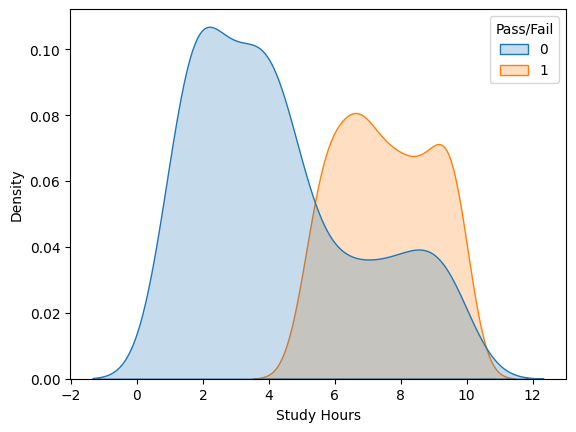

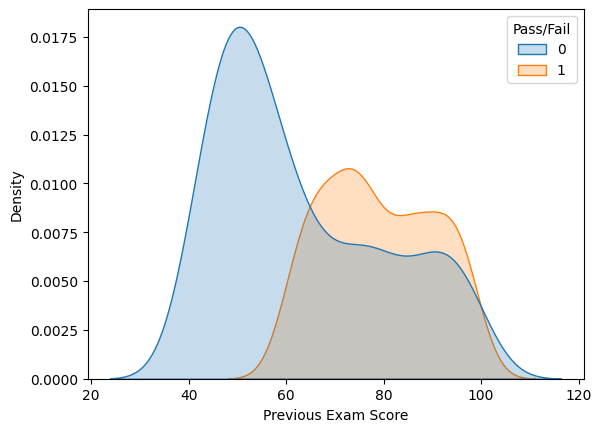

In [25]:
for i in data.drop('Pass/Fail', axis=1).columns:
    sns.kdeplot(data=data, x=i, hue='Pass/Fail', fill=True)
    plt.show()

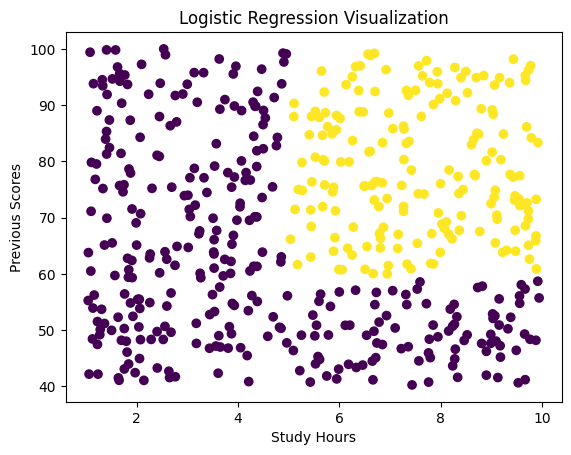

In [30]:
plt.scatter(
    data['Study Hours'],
    data['Previous Exam Score'],
    c=data['Pass/Fail']
)

plt.title("Logistic Regression Visualization")
plt.xlabel("Study Hours")
plt.ylabel("Previous Scores")

plt.show()

Training the model on Logistic Regression model

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score

In [53]:
# train test split
X = data.drop('Pass/Fail', axis=1)
Y = data['Pass/Fail']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=2)

In [54]:
model = LogisticRegression(lr=0.01, no_of_it=1000)

In [55]:
model.fit(X_train,Y_train)

In [56]:
y_pred = model.predict(X_test)

In [57]:
print("Accuracy is :",accuracy_score(Y_test,y_pred))
print("Precision is :",precision_score(Y_test,y_pred))
print("Recall is :",recall_score(Y_test,y_pred))
print("F1 score is :",f1_score(Y_test,y_pred))
print("ROC AUC score is :",roc_auc_score(Y_test,y_pred))

Accuracy is : 0.5
Precision is : 0.38271604938271603
Recall is : 1.0
F1 score is : 0.5535714285714286
ROC AUC score is : 0.6376811594202898


Now Train the model by built-in sklearn liberies

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# sklearn model
model = LogisticRegression(
    penalty=None,
    max_iter=10000
)

model.fit(X_train_scaled, Y_train)

y_pred = model.predict(X_test_scaled)

In [64]:
print("Accuracy is :",accuracy_score(Y_test,y_pred))
print("Precision is :",precision_score(Y_test,y_pred))
print("Recall is :",recall_score(Y_test,y_pred))
print("F1 score is :",f1_score(Y_test,y_pred))
print("ROC AUC score is :",roc_auc_score(Y_test,y_pred))

Accuracy is : 0.87
Precision is : 0.8
Recall is : 0.7741935483870968
F1 score is : 0.7868852459016393
ROC AUC score is : 0.8436185133239832
